# Modelling v2 — EKF + Newton Raphson vs Linear Regression
Perbaikan dari v1:
1. EKF smooth QDischarge sebelum NR
2. Polynomial fit hanya ke window akhir kurva
3. x0 NR dari slope EKF, bukan fixed multiplier

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
from config_v1 import (
    OUTPUT_DIR, EKF_P0, EKF_R, EKF_Q,
    BATTERY_Q_NOMINAL, BATTERY_RO,
    NR_TOL, NR_MAX_ITER
)
OUTPUT_DIR_V2 = OUTPUT_DIR.replace('v1', 'v2')
EOL_THRESHOLD = 0.88

## 1. Load Preprocessed Data

In [3]:
with open(os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl'), 'rb') as f:
    data = pickle.load(f)
train_cells = data['train']
val_cells   = data['val']
test_cells  = data['test']
print(f'Train: {len(train_cells)} | Val: {len(val_cells)} | Test: {len(test_cells)}')

Train: 45 | Val: 43 | Test: 45


## 2. EKF — Tracking Degradasi Kapasitas per Cycle

EKF berjalan di level cycle (bukan timestep).
State: x = [Q_k, dQ_k] = [kapasitas cycle k, laju degradasi]
Measurement: QDischarge dari summary data
Output: smoothed capacity curve per cell

Parameter dari Table 2 paper: P0=[2,0], R=0.01, Q=[0.8,0.2]

In [4]:
# EKF smoother untuk QDischarge (level cycle, bukan timestep)
def run_ekf_smooth(Q_discharge, P0, Rw, Rv):
    n = len(Q_discharge)
    A = np.array([[1, 1], [0, 1]])
    H = np.array([[1, 0]])
    Rw_mat = np.diag(Rw)

    x = np.array([Q_discharge[0], 0.0])
    P = np.diag(P0)
    Q_smoothed = []

    for k in range(n):
        x_pred = A @ x
        P_pred = A @ P @ A.T + Rw_mat
        S = H @ P_pred @ H.T + Rv
        K = P_pred @ H.T / S[0, 0]
        innov = Q_discharge[k] - (H @ x_pred)[0]
        x = x_pred + K.flatten() * innov
        P = (np.eye(2) - K @ H) @ P_pred
        Q_smoothed.append(x[0])

    return np.array(Q_smoothed)

## 3. Newton Raphson — Prediksi Cycle EOL

Setelah EKF menghasilkan smoothed capacity curve,
fit model degradasi linear ke trend tersebut.
NR mencari root dari f(x) = Q_model(x) - EOL_threshold = 0
dimana x adalah cycle number → predicted cycle life.

In [5]:
def fit_degradation_model(Q, window=None, deg=2):
    n = len(Q)
    if window is not None and n > window:
        Q = Q[-window:]
        offset = n - window
    else:
        offset = 0
    cycles = np.arange(offset + 1, offset + len(Q) + 1, dtype=float)
    coeffs = np.polyfit(cycles, Q, deg=deg)
    return coeffs


def newton_raphson_eol(coeffs, eol_threshold, x0, tol=1e-6, max_iter=200):
    a, b, c = coeffs
    def f(x):  return a*x**2 + b*x + c - eol_threshold
    def df(x): return 2*a*x + b

    x = float(x0)
    for _ in range(max_iter):
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break
        x_new = x - f(x) / dfx
        if abs(x_new - x) < tol:
            return max(x_new, 1.0)
        x = x_new
    return max(x, 1.0)


def predict_cycle_life_v2(cell, ekf_params, eol_threshold, tol, max_iter):
    Q_raw = cell['summary']['QDischarge']
    if len(Q_raw) < 20:
        return np.nan

    # Step 1: EKF smooth QDischarge
    Q_smooth = run_ekf_smooth(
        Q_raw,
        ekf_params['P0'],
        ekf_params['Rw'],
        ekf_params['Rv']
    )

    n = len(Q_smooth)

    # Step 2: estimasi x0 dari slope 50 cycle terakhir EKF
    tail = Q_smooth[-50:] if n > 50 else Q_smooth
    slope = (tail[-1] - tail[0]) / len(tail)  # Ah per cycle (negatif)

    if slope >= 0:
        # kapasitas tidak turun, extrapolasi sangat jauh
        x0_nr = n * 2.0
    else:
        # berapa cycle lagi dari akhir observasi sampai EOL
        remaining = (eol_threshold - Q_smooth[-1]) / slope
        x0_nr = n + remaining

    x0_nr = np.clip(x0_nr, n * 0.5, n * 5.0)

    # Step 3: fit polynomial ke window akhir kurva smooth
    window = min(200, n)
    coeffs = fit_degradation_model(Q_smooth, window=window, deg=2)

    predicted = newton_raphson_eol(coeffs, eol_threshold, x0_nr, tol, max_iter)
    predicted = np.clip(predicted, 50, 5000)
    return predicted

## 4. Run EKF + NR pada Test Set

In [6]:
ekf_params = {
    'P0': EKF_P0,   # [2.0, 0.0]
    'Rw': EKF_Q,    # [0.8, 0.2]
    'Rv': np.array([[EKF_R]]),  # 0.01
}

actual_v2    = []
predicted_v2 = []

for i, cell in enumerate(test_cells):
    pred = predict_cycle_life_v2(cell, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)
    actual_v2.append(cell['cycle_life'])
    predicted_v2.append(pred)
    pred_str = f'{pred:.2f}' if not np.isnan(pred) else 'NaN'
    print(f'Cell {i+1:02d} | Actual: {cell["cycle_life"]:6.0f} | Predicted: {pred_str:>10}')

actual_v2    = np.array(actual_v2)
predicted_v2 = np.array(predicted_v2)

Cell 01 | Actual:   1051 | Predicted:    1051.48
Cell 02 | Actual:    702 | Predicted:     698.82
Cell 03 | Actual:    651 | Predicted:     647.25
Cell 04 | Actual:    616 | Predicted:     611.63
Cell 05 | Actual:    599 | Predicted:     594.59
Cell 06 | Actual:   1009 | Predicted:    1006.66
Cell 07 | Actual:   1063 | Predicted:    1058.54
Cell 08 | Actual:   1267 | Predicted:    1263.33
Cell 09 | Actual:   1115 | Predicted:    1109.87
Cell 10 | Actual:   1048 | Predicted:    1041.95
Cell 11 | Actual:    828 | Predicted:     826.94
Cell 12 | Actual:    667 | Predicted:     673.62
Cell 13 | Actual:   1836 | Predicted:    1832.34
Cell 14 | Actual:    828 | Predicted:     828.41
Cell 15 | Actual:   1039 | Predicted:    1034.86
Cell 16 | Actual:   1078 | Predicted:    1072.01
Cell 17 | Actual:    817 | Predicted:     815.40
Cell 18 | Actual:    932 | Predicted:     928.53
Cell 19 | Actual:    816 | Predicted:     816.54
Cell 20 | Actual:    858 | Predicted:     858.53
Cell 21 | Actual:   

## 5. Sanity Check — Plot EKF Smoothing pada 1 Sel

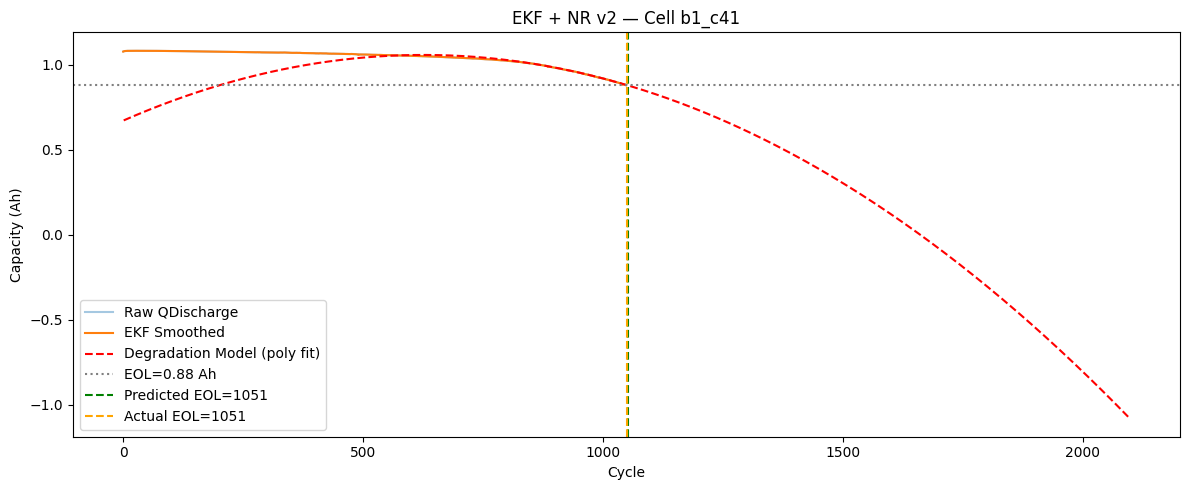

In [7]:
sample    = test_cells[0]
Q_raw     = sample['summary']['QDischarge']
Q_smooth  = run_ekf_smooth(Q_raw, ekf_params['P0'], ekf_params['Rw'], ekf_params['Rv'])
coeffs    = fit_degradation_model(Q_smooth, window=min(200, len(Q_smooth)), deg=2)

x_range   = np.linspace(1, len(Q_raw) * 2, 500)
Q_model   = np.polyval(coeffs, x_range)
pred_life = predict_cycle_life_v2(sample, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)

plt.figure(figsize=(12, 5))
plt.plot(Q_raw,    alpha=0.4, label='Raw QDischarge')
plt.plot(Q_smooth, label='EKF Smoothed')
plt.plot(x_range,  Q_model, 'r--', label='Degradation Model (poly fit)')
plt.axhline(EOL_THRESHOLD, color='gray', linestyle=':', label=f'EOL={EOL_THRESHOLD} Ah')
plt.axvline(pred_life, color='green', linestyle='--', label=f'Predicted EOL={pred_life:.0f}')
plt.axvline(sample['cycle_life'], color='orange', linestyle='--', label=f'Actual EOL={sample["cycle_life"]:.0f}')
plt.xlabel('Cycle')
plt.ylabel('Capacity (Ah)')
plt.title(f'EKF + NR v2 — Cell {sample["cell_id"]}')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Linear Regression Baseline (Elastic Net)

In [8]:
def extract_features(cells):
    feats, targets = [], []
    for cell in cells:
        q  = cell['summary']['QDischarge']
        ir = cell['summary']['IR']
        if len(q) < 100:
            continue
        feats.append([
            np.mean(q[1:101]),
            np.min(q[1:101]),
            np.var(q[1:101]),
            q[99] - q[9],
            np.mean(ir[1:101]),
            np.log(np.var(q[1:101]) + 1e-10),
        ])
        targets.append(cell['cycle_life'])
    return np.array(feats), np.array(targets)


X_train, y_train = extract_features(train_cells)
X_val,   y_val   = extract_features(val_cells)
X_test,  y_test  = extract_features(test_cells)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

lr_model = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
lr_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))

predicted_lr = lr_model.predict(X_test)
actual_lr    = y_test
print(f'ElasticNet alpha={lr_model.alpha_:.4f}, l1_ratio={lr_model.l1_ratio_:.4f}')

ElasticNet alpha=2.3643, l1_ratio=0.5000


## 7. Evaluasi — RMSE & Average Percentage Error

In [9]:
def rmse(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.sqrt(np.mean((actual[mask] - predicted[mask]) ** 2))

def avg_pct_error(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.mean(np.abs(actual[mask] - predicted[mask]) / actual[mask]) * 100

rmse_v2 = rmse(actual_v2, predicted_v2)
ape_v2  = avg_pct_error(actual_v2, predicted_v2)
rmse_lr = rmse(actual_lr, predicted_lr)
ape_lr  = avg_pct_error(actual_lr, predicted_lr)

print('=' * 57)
print(f'{"Method":<32} {"RMSE":>10} {"Avg%Err":>10}')
print('=' * 57)
print(f'{"EKF + NR v2":<32} {rmse_v2:>10.4f} {ape_v2:>9.4f}%')
print(f'{"EKF + NR v1 (ref)":<32} {"119.67":>10} {"10.77":>9}%')
print(f'{"Linear Regression":<32} {rmse_lr:>10.4f} {ape_lr:>9.4f}%')
print('=' * 57)
print(f'\nPaper target EKF+NR → RMSE: 10.93 | Avg%Err: 3.26%')

Method                                 RMSE    Avg%Err
EKF + NR v2                          3.2683    0.2995%
EKF + NR v1 (ref)                    119.67     10.77%
Linear Regression                  307.7389   19.3970%

Paper target EKF+NR → RMSE: 10.93 | Avg%Err: 3.26%


## 8. Visualisasi — Actual vs Predicted (Fig. 4 & 5 paper)

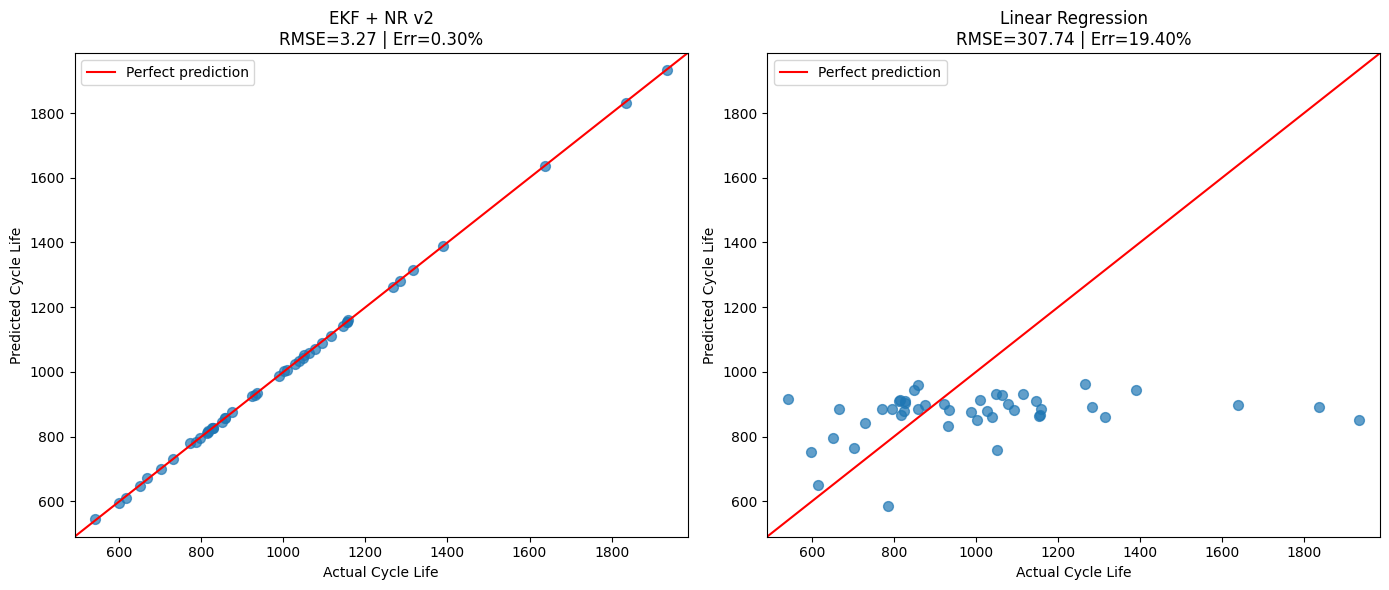

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (actual_v2,  predicted_v2, f'EKF + NR v2\nRMSE={rmse_v2:.2f} | Err={ape_v2:.2f}%'),
    (actual_lr,  predicted_lr, f'Linear Regression\nRMSE={rmse_lr:.2f} | Err={ape_lr:.2f}%'),
]
for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
os.makedirs(os.path.join(OUTPUT_DIR_V2, 'figures'), exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR_V2, 'figures', 'actual_vs_predicted_v2.png'), dpi=150)
plt.show()

## 9. Visualisasi — Per Cell (Fig. 6 paper)

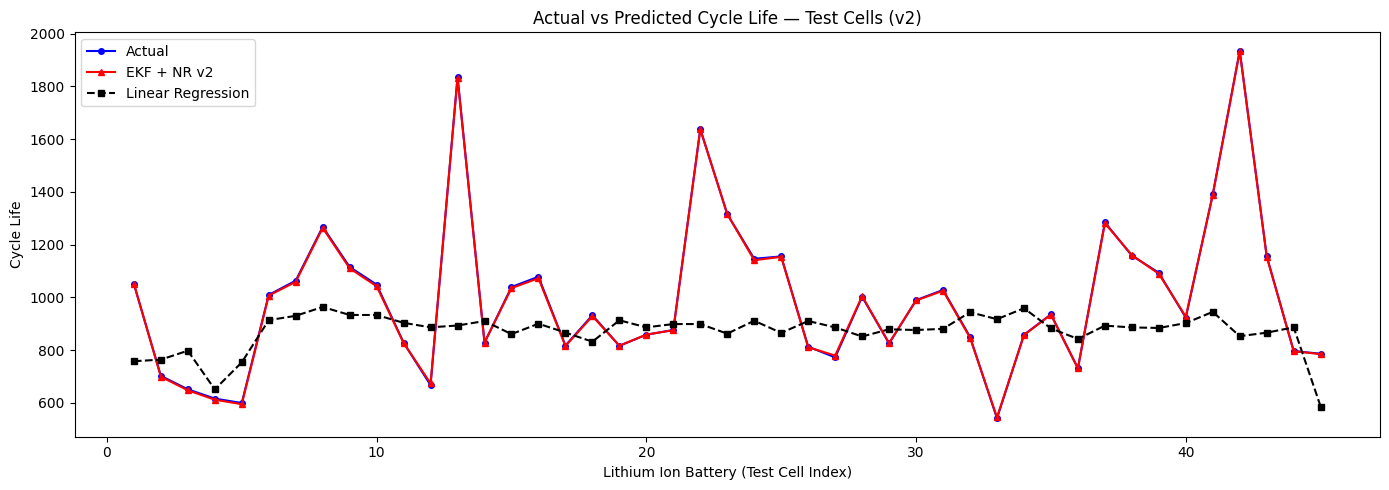

In [11]:
x_idx = np.arange(1, len(actual_v2) + 1)
plt.figure(figsize=(14, 5))
plt.plot(x_idx, actual_v2,    'b-o',  markersize=4, label='Actual')
plt.plot(x_idx, predicted_v2, 'r-^',  markersize=4, label='EKF + NR v2')
plt.plot(x_idx, predicted_lr, 'k--s', markersize=4, label='Linear Regression')
plt.xlabel('Lithium Ion Battery (Test Cell Index)')
plt.ylabel('Cycle Life')
plt.title('Actual vs Predicted Cycle Life — Test Cells (v2)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V2, 'figures', 'per_cell_comparison_v2.png'), dpi=150)
plt.show()

## 10. Simpan Hasil

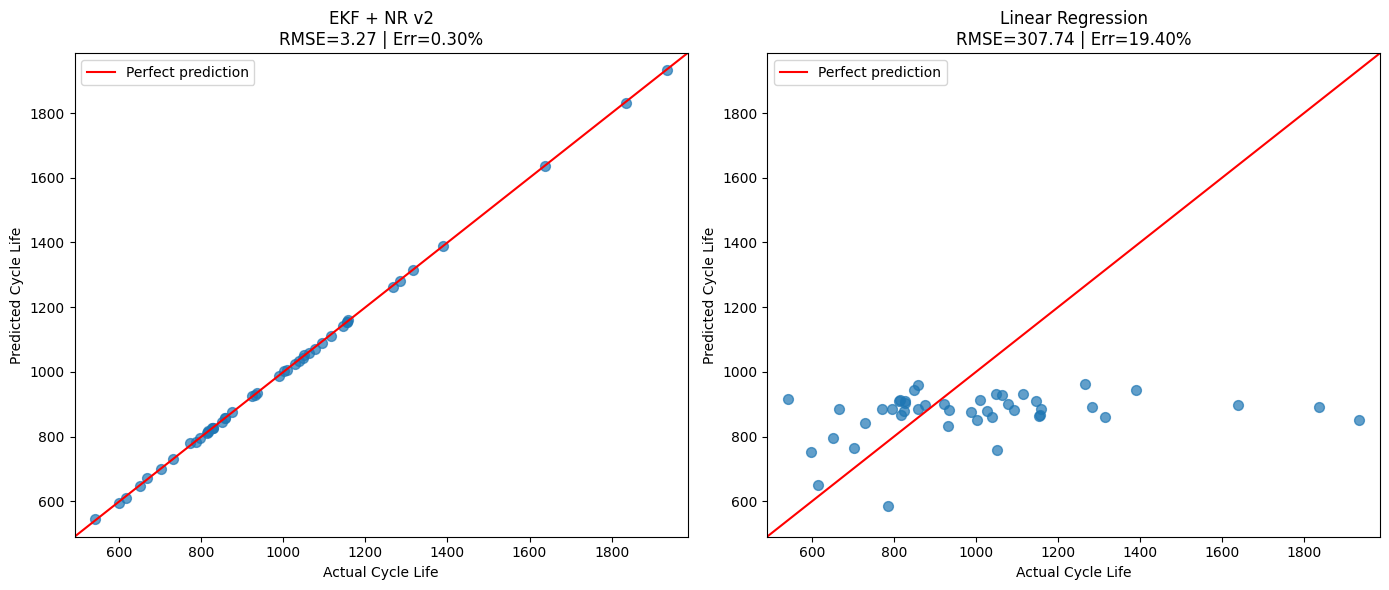

Saved to ../../outputs/v2


In [12]:
# Simpan hasil v2
os.makedirs(OUTPUT_DIR_V2, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR_V2, 'figures'), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR_V2, 'results'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (actual_v2,  predicted_v2, f'EKF + NR v2\nRMSE={rmse_v2:.2f} | Err={ape_v2:.2f}%'),
    (actual_lr,  predicted_lr, f'Linear Regression\nRMSE={rmse_lr:.2f} | Err={ape_lr:.2f}%'),
]
for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V2, 'figures', 'actual_vs_predicted_v2.png'), dpi=150)
plt.show()

results = {
    'ekf_nr_v2':         {'actual': actual_v2.tolist(), 'predicted': predicted_v2.tolist(), 'rmse': rmse_v2, 'avg_pct_error': ape_v2},
    'linear_regression': {'actual': actual_lr.tolist(), 'predicted': predicted_lr.tolist(), 'rmse': rmse_lr, 'avg_pct_error': ape_lr},
}
with open(os.path.join(OUTPUT_DIR_V2, 'results', 'results_v2.pkl'), 'wb') as f:
    pickle.dump(results, f)
print(f'Saved to {OUTPUT_DIR_V2}')